# How can I preserve weather and streamflow inputs together?

An analysis that reads NOAA station weather and USGS streamflow depends on two
agencies' query services, each of which can revise its answer. This study
pins both behind one manifest and one lockfile: a month of daily
precipitation and maximum temperature at Will Rogers World Airport in Oklahoma
City, and daily mean discharge of the Arkansas River at Tulsa, for May 2024.
It then verifies the inputs and restores them into an empty cache.

The two sites are about 170 km apart and in different river basins, so the
figure below sets them side by side without inferring that one caused the
other. The study needs `usdata[pandas]` and matplotlib, downloads two small
CSVs, and runs in a few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T06:03:02+00:00
usdata 0.26.0; pandas 3.0.6


## Data

- [Daily station observations](https://usdata.dev/datasets/noaa/ghcn-daily/)
  (GHCN-Daily): precipitation (`PRCP`) and maximum temperature (`TMAX`) at
  station USW00013967, requested in metric units.
- [Daily water observations](https://usdata.dev/datasets/usgs/water-daily/):
  discharge (parameter `00060`) as a daily mean (statistic `00003`) at USGS
  site 07164500, Arkansas River at Tulsa. The response carries its own units
  and approval status on every row.

Quoted identifiers and codes preserve their leading zeros.

In [2]:
print(manifest.read_text())

name: weather-and-streamflow
version: "1.0"
sources:
  - dataset: noaa:ghcn-daily
    start: 2024-05-01
    end: 2024-05-31
    variables: [PRCP, TMAX]
    params:
      stations: USW00013967
      units: metric
  - dataset: usgs:water-daily
    start: 2024-05-01
    end: 2024-05-31
    variables: ["00060"]
    params:
      sites: "07164500"
      statistic_id: "00003"



## Pull and open both sources

A first pull resolves both sources, downloads their files, records
provenance, and writes a lockfile. Later pulls restore the pinned inputs. Each
source can arrive as more than one file, so the files are grouped by dataset
before they are concatenated. USGS rows do not arrive in date order, so both
tables are sorted by date.

In [3]:
result = pull(manifest)
frames = {}
for item in result.fetched:
    frames.setdefault(item.asset.dataset_id, []).append(item.open())
weather = pd.concat(frames["noaa:ghcn-daily"], ignore_index=True)
streamflow = pd.concat(frames["usgs:water-daily"], ignore_index=True)
weather["DATE"] = pd.to_datetime(weather["DATE"])
streamflow["time"] = pd.to_datetime(streamflow["time"])
weather = weather.sort_values("DATE", ignore_index=True)
streamflow = streamflow.sort_values("time", ignore_index=True)
print(f"NOAA weather: {len(weather)} days; PRCP in mm and TMAX in °C (requested metric)")
display(weather[["STATION", "DATE", "PRCP", "TMAX"]].head(3))
print(f"USGS streamflow: {len(streamflow)} days; units and approval status per row")
columns = ["time", "monitoring_location_id", "parameter_code", "value", "unit_of_measure"]
columns.append("approval_status")
display(streamflow[columns].head(3))

NOAA weather: 31 days; PRCP in mm and TMAX in °C (requested metric)


,STATION,DATE,PRCP,TMAX
0,USW00013967,2024-05-01,9.1,26.1
1,USW00013967,2024-05-02,15.2,22.8
2,USW00013967,2024-05-03,0.0,26.1


USGS streamflow: 31 days; units and approval status per row


,time,monitoring_location_id,parameter_code,value,unit_of_measure,approval_status
0,2024-05-01,USGS-07164500,00060,8430,ft^3/s,Approved
1,2024-05-02,USGS-07164500,00060,6980,ft^3/s,Approved
2,2024-05-03,USGS-07164500,00060,4460,ft^3/s,Approved


Each asset has its own source URL, retrieval time, size, and SHA-256 checksum.
These describe the downloaded bytes. DataFrame edits or exported analyses need
their own provenance; they do not change the raw input record.

In [4]:
for item in result.fetched:
    print(item.asset.dataset_id)
    print(f"Bytes: {item.provenance.size}; cache hit: {item.from_cache}")
    print("Source:", item.provenance.source_url)
    print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
    print("Checksum:", item.provenance.checksum)
    print()

noaa:ghcn-daily
Bytes: 2271; cache hit: False
Source: https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&stations=USW00013967&startDate=2024-05-01&endDate=2024-05-31&format=csv&units=metric&includeStationLocation=1&dataTypes=PRCP%2CTMAX
Retrieved (UTC): 2026-09-24T06:03:02+00:00
Checksum: sha256:4412651ac30f2428ec68db1cd9d151650dd29707445d603e09a0c003cc59e06e

usgs:water-daily
Bytes: 5390; cache hit: False
Source: https://api.waterdata.usgs.gov/ogcapi/v0/collections/daily/items?f=csv&time=2024-05-01%2F2024-05-31&statistic_id=00003&limit=10000&monitoring_location_id=USGS-07164500&parameter_code=00060&offset=0
Retrieved (UTC): 2026-09-24T06:03:03+00:00
Checksum: sha256:17f870de9bc7fd6ad948ed19770c2e966e02761af77c3e370bb50462946ec9a3



## Side by side

Daily precipitation at the airport above, daily mean discharge at Tulsa below,
on one calendar. The units differ because the agencies differ: NOAA converted
to millimetres on request, and USGS reports cubic feet per second.

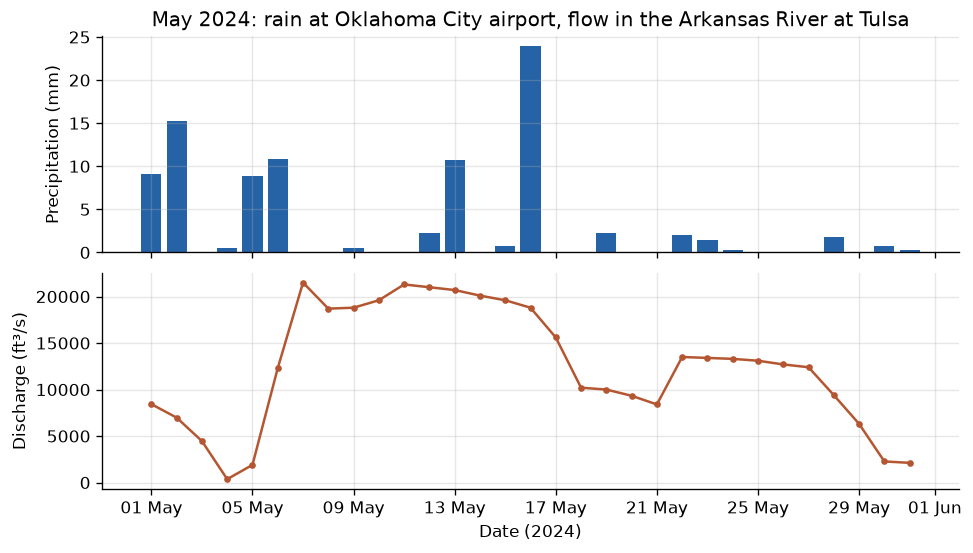

In [5]:
fig, (rain, river) = plt.subplots(2, 1, sharex=True, layout="constrained")
rain.bar(weather["DATE"], weather["PRCP"], width=0.8, color="#2563a6")
rain.set_ylabel("Precipitation (mm)")
rain.set_title("May 2024: rain at Oklahoma City airport, flow in the Arkansas River at Tulsa")
river.plot(streamflow["time"], streamflow["value"], marker=".", color="#b45631")
river.set_ylabel("Discharge (ft³/s)")
river.set_xlabel("Date (2024)")
river.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.show()

In [6]:
wettest = weather.loc[weather["PRCP"].idxmax()]
peak = streamflow.loc[streamflow["value"].idxmax()]
low = streamflow.loc[streamflow["value"].idxmin()]
print(f"Airport precipitation for the month: {weather['PRCP'].sum():.1f} mm")
print(f"Wettest day: {wettest['DATE']:%d %B} with {wettest['PRCP']:.1f} mm")
print(f"Days with measurable rain: {int((weather['PRCP'] > 0).sum())}")
print(f"Tulsa discharge ranged {low['value']:,.0f} to {peak['value']:,.0f} ft³/s")
print(f"Highest daily mean: {peak['time']:%d %B}")
print(f"Approval status: {streamflow['approval_status'].value_counts().to_dict()}")

Airport precipitation for the month: 91.8 mm
Wettest day: 16 May with 23.9 mm
Days with measurable rain: 17
Tulsa discharge ranged 365 to 21,500 ft³/s
Highest daily mean: 07 May
Approval status: {'Approved': 31}


The two series share a calendar, not a watershed: rain at Oklahoma City runs
off toward the North Canadian and Canadian rivers, which reach the Arkansas
well below Tulsa. The Tulsa gauge also lies below Keystone Dam, so its flow
follows reservoir releases as well as rain. Rain at one airport stands in for
storms that crossed the state, not for the water passing Tulsa.

## Pin and cite

`verify` checks the manifest and cached bytes against the lockfile, offline.
A second pull loads the lockfile and reuses the verified cache without asking
either agency again. Restoring into a new temporary cache downloads the pinned
files again and checks their original checksums, leaving the files from the
earlier cells intact; if upstream has revised the bytes, restoration fails
with a checksum mismatch rather than silently changing the inputs.

To explore another input set, edit the manifest's station, site, dates, or
variables, then use `pull(manifest, force=True)` when you intentionally want a
new lockfile. See the
[manifest reference](https://docs.usdata.dev/reference/manifests/) for the
complete contract.

In [7]:
assert verify(manifest) == []
again = pull(manifest)
print(f"Restored from lockfile: {again.from_lockfile}")
print(f"All assets came from cache: {all(item.from_cache for item in again.fetched)}")
with TemporaryDirectory(prefix="usdata-restore-") as directory:
    restored = pull(manifest, root=Path(directory))
    assert verify(manifest, root=Path(directory)) == []
    downloaded = sum(not item.from_cache for item in restored.fetched)
    print(f"Fresh cache: {downloaded} pinned assets downloaded and verified")
print()
for citation in cite_lockfile(manifest):
    print(citation.as_text())

Restored from lockfile: True
All assets came from cache: True


Fresh cache: 2 pinned assets downloaded and verified

noaa:ghcn-daily
  Menne, M.J., I. Durre, R.S. Vose, B.E. Gleason, and T.G. Houston, 2012: An overview of the Global Historical Climatology Network-Daily Database. Journal of Atmospheric and Oceanic Technology, 29, 897-910, doi:10.1175/JTECH-D-11-00103.1
  homepage: https://www.ncei.noaa.gov/products/land-based-station/global-historical-climatology-network-daily
  license: US Government Work (public domain)
  terms: https://www.ncei.noaa.gov/metadata/geoportal/rest/metadata/item/gov.noaa.ncdc:C00861/html
  retrieved: 2026-09-24; 1 checksummed asset (2,271 bytes) pinned by usdata 0.26.0
  sources: 1
usgs:water-daily
  U.S. Geological Survey, Water Data for the Nation daily values, accessed via usdata
  homepage: https://api.waterdata.usgs.gov/
  license: US Government Work (public domain)
  terms: https://www.usgs.gov/information-policies-and-instructions/copyrights-and-credits
  retrieved: 2026-09-24; 1 checksummed asset (5,390 bytes

## What was awkward

- The two agencies' tables share no column names or identifier forms: NOAA's
  `STATION` and `DATE` against USGS's `monitoring_location_id` and `time`, and
  the site requested as `07164500` comes back as `USGS-07164500`. Every join
  across them is by hand.
- Units live in different places. The GHCN CSV has no units row, so the
  manifest's `units: metric` is the only record that `PRCP` is millimetres;
  USGS repeats `ft^3/s` on every row, and the manifest cannot ask it for metric.
- USGS daily rows arrive in no particular date order (the service rejects
  sorting beyond its first page), so a line plot drawn straight from the file
  zigzags across the month until the table is sorted.
- Parameter, statistic, and site codes are numeric-looking strings with
  leading zeros, and must be quoted in YAML.
- Nothing in the manifest relates the weather station to the gauge. Choosing
  a station in the gauge's drainage area is left to the analyst, and this
  pair is not one.
- Both are query services that revise their answers: GHCN-Daily receives late
  reports and quality control, and USGS daily values stay provisional until
  approved. A checksum detects a revision but cannot recreate bytes upstream
  no longer serves, so keep the cached bytes with the manifest and lockfile.